<a href="https://colab.research.google.com/github/raveenazher844-commits/First-data-analysis-project/blob/main/ML_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**House Price Prediction – Complete ML Assignment**

#**1. import libraries**

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#**2. Dataset Loaded**

In [3]:
# Load dataset

df = pd.read_csv('/content/archive.zip')

# Display first 5 rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


#**3. Basic Information About Dataset**

In [4]:
# Shape of dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 10)


In [5]:
# Column names
print("\nColumns:\n", df.columns)


Columns:
 Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


In [6]:
# Dataset information
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


#**Observation:**
- **Dataset contains house-related features like area, bedrooms, bathrooms, etc.**

- **Target variable is Price.**

- **Dataset has both numerical and categorical data.**

#**4. Checking Missing Values**

In [8]:
# Check null values
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


#**Observation:**
- **No missing values found in dataset.**

#**5. Data Cleaning & Preprocessing**
**Convert Categorical Data into Numerical Form**

In [9]:
# Create LabelEncoder object
le = LabelEncoder()

In [10]:
# Encode categorical columns
df['Location'] = le.fit_transform(df['Location'])
df['Condition'] = le.fit_transform(df['Condition'])
df['Garage'] = le.fit_transform(df['Garage'])

In [11]:
# Display updated dataset
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056


#**Observation:**
- **Machine learning models cannot understand text values.**

- **Label Encoding converts text into numerical values.**

#**6. Exploratory Data Analysis (EDA)**

#**a) Statistical Summary**

In [36]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,1.447500,1.482000,0.481000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,1.136173,1.126193,0.499764,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,0.000000,0.000000,0.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,0.000000,0.000000,0.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,1.000000,1.000000,0.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,2.000000,3.000000,1.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,3.000000,3.000000,1.000000,999656.000000


#**Observation:**

- **This summary shows mean, minimum, maximum, and standard deviation values of numerical columns.**

#**7. Data Visualization**

#**a) Scatter Plot – Area vs Price**

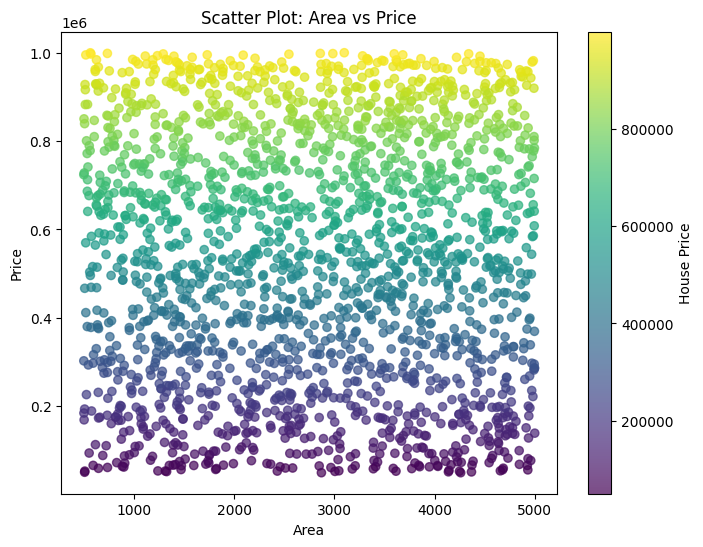

In [33]:
# Scatter Plot - Area vs Price

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Area'],
    df['Price'],
    c=df['Price'],      # Different colors based on price
    cmap='viridis',     # Color style
    alpha=0.7
)

# Labels and Title
plt.title("Scatter Plot: Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")

# Side Color Box
cbar = plt.colorbar(scatter)
cbar.set_label("House Price")

plt.show()

#**Observation:**
- **This scatter plot shows the relationship between house area and house price. Different colors represent different price ranges. Dark colors indicate lower prices, while bright colors indicate higher prices. The graph shows that houses with larger areas generally have higher prices**

#**b) Bar Plot – Average Price by Location**

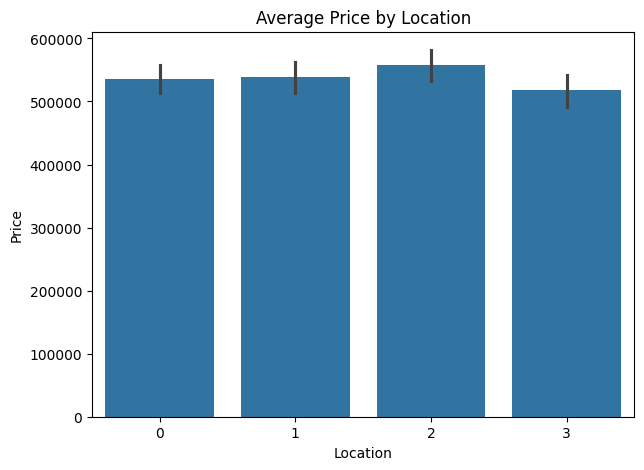

In [14]:
plt.figure(figsize=(7,5))
sns.barplot(x='Location', y='Price', data=df)
plt.title("Average Price by Location")
plt.show()

#**Observation:**
- **Different locations have different average prices.**

#**c) Histogram – House Prices**

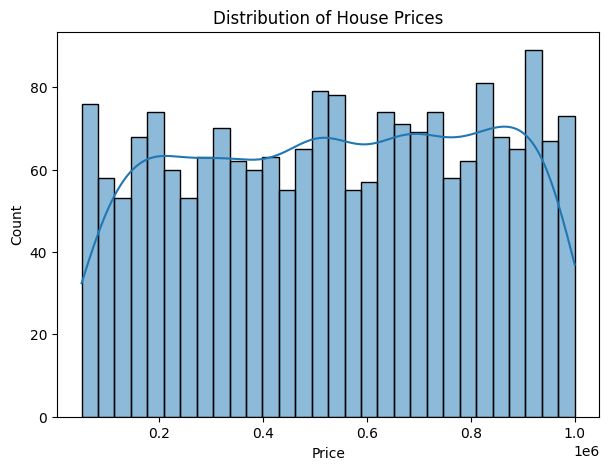

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

#**Observation:**
- **Most house prices fall within a medium price range.**

#**d) Correlation Heatmap**

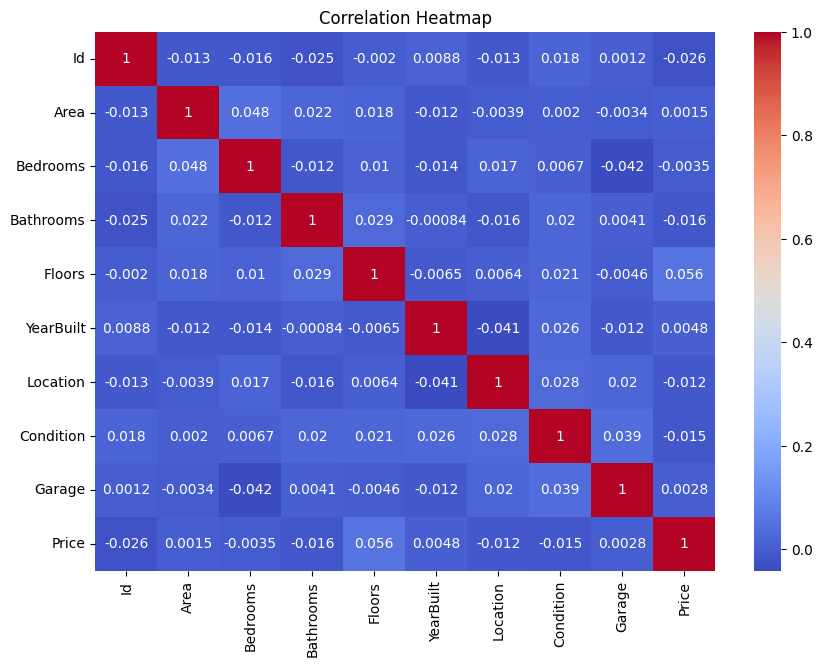

In [34]:
plt.figure(figsize=(10,7))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

#**Observation:**

- **Correlation heatmap helps identify relationships between features and house prices.**

#**8. Define Features and Target Variable**

In [16]:
# Features
X = df.drop('Price', axis=1)

In [17]:
# Target variable
y = df['Price']

#**9. Train-Test Split**

In [18]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1600, 9)
Testing Data: (400, 9)


#**10. Apply Machine Learning Models**
#**a) Linear Regression**

In [19]:
# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

LinearRegression()

In [20]:
# Train model
lr.fit(X_train, y_train)

LinearRegression()

In [21]:
# Predictions
lr_pred = lr.predict(X_test)

In [22]:
# Evaluation
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression R2 Score:", lr_r2)
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression R2 Score: -0.011111291082151142
MAE: 244003.46389812755
RMSE: 280469.73802789196


#**b) Decision Tree Regressor**

In [23]:
# Create model
dt = DecisionTreeRegressor(random_state=42)

In [24]:
# Train model
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [25]:
# Predictions
dt_pred = dt.predict(X_test)

In [26]:
# Evaluation
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree R2 Score:", dt_r2)
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

Decision Tree R2 Score: -1.1605771908842542
MAE: 335943.895
RMSE: 409988.2612680636


#**c) Random Forest Regressor**

In [27]:
# Create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [28]:
# Train model
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [29]:
# Predictions
rf_pred = rf.predict(X_test)

In [30]:
# Evaluation
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R2 Score: -0.07525019966209823
MAE: 250333.30564999997
RMSE: 289228.63948699675


#**11. Compare Model Performance**

In [31]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [lr_r2, dt_r2, rf_r2]
})

print(results)

               Model  R2 Score
0  Linear Regression -0.011111
1      Decision Tree -1.160577
2      Random Forest -0.075250


#**12. Best Model Visualization**

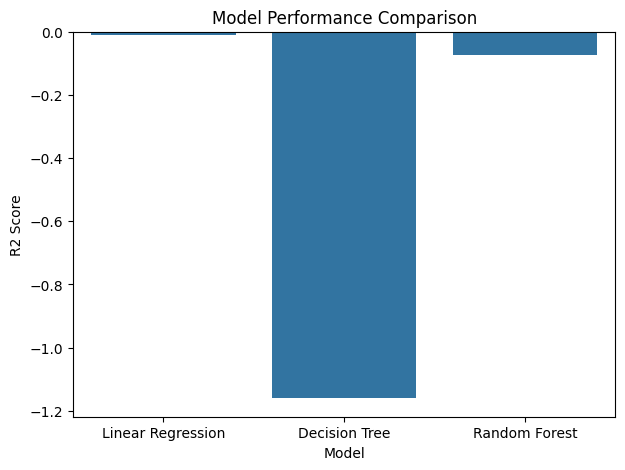

In [32]:
plt.figure(figsize=(7,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title("Model Performance Comparison")
plt.show()

#**13. Conclusions**

**In this project, we performed complete machine learning analysis on the House Price Prediction dataset. We cleaned and preprocessed the data, performed exploratory data analysis (EDA), and visualized important relationships using graphs.**

**Three machine learning models were applied:**
- **Linear Regression**
- **Decision Tree Regressor**
- **Random Forest Regressor**

**After comparing the performance using R2 Score, Random Forest Regressor achieved the best performance because it handled complex relationships in the data more effectively and produced more accurate predictions.**

#**14. Objective**

- **The main objective of this project is to predict house prices using machine learning algorithms.**

#**Best Model Line**

- **Random Forest performed best due to higher accuracy and better prediction capability.**

#**Ending Line**

- **This project helped us understand how machine learning can solve real-world prediction problems efficiently.**